In [68]:
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt

from utils.display_tools import load_best_forecasts,  display_predictions_2


In [69]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
lot = pickle.load(open("../saves_and_results/cache_lot.p", "rb"))
data = pickle.load(open("../saves_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

## Draw some point

In [73]:
d = data["Moehne"]["desc1"]
y_ = d.loc[d.index.year == 2020]
ps_id = "11176"
cm_subsection = linspace(0, 1, 7)
colors_add = iter([cm.Accent(x) for x in cm_subsection])

colors_add = list(colors_add)
colors = {
"ari":colors_add[3],
"for": colors_add[1],
"ada": colors_add[2],
"lin": colors_add[0],
"var": colors_add[4],
"chr": colors_add[5],
"tfm": colors_add[6]
}

In [76]:
ms = {}
fc = {}
mae = {}

for x in [str(n) for n in range(0, 4)]:
    model_spec, forecasts = load_best_forecasts(
        "results/journal/" + x, direction="desc1"
    )
    stack = []
    for model_type in forecasts.keys():
        stack.append(forecasts[model_type][ps_id])
    naming = forecasts.keys()
    forecasts = pd.concat(stack, axis=1)
    forecasts.columns = naming
    if (x == "1") or (x == "2"):
        forecasts.drop(columns="sarimax", inplace=True)
    if x == "2":
        forecasts.drop(columns="var", inplace=True)

    score = pd.DataFrame(
        [np.abs(forecasts[x] - y_[ps_id].values).mean() for x in forecasts.columns],
        index=forecasts.columns,
        columns=["MAE"],
    )
    fc[x] = forecasts
    fc[x].columns = [x  if x != "sar" else "ari" for x in fc[x].columns.str[:3]]
    mae[x] = score
    mae[x].index = [x  if x != "sar" else "ari" for x in mae[x].index.str[:3]]
    mae[x] = score.round(2)


chronos = pd.read_csv(
    "results/journal/chronos/Moehne_desc1_chronos_zero_shot_chronos.csv", index_col=0)[ps_id]
tfm = pd.read_csv(
    "results/journal/tfm/Moehne_desc1_tfm_zero_shot_chronos.csv", index_col=0)[ps_id]
# append foundational models
fc["3"]["chr"] = chronos.values[:-1]
fc["3"]["tfm"] = tfm.values[:-1]
mae["3"] = mae["3"].T
mae["3"]["chr"] = np.abs(y_[ps_id] - chronos.values[:-1]).mean()
mae["3"]["tfm"] = np.abs(y_[ps_id] - tfm.values[:-1]).mean()
mae["3"] = mae["3"].T


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:193: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = list(np.where(d.index.weekofyear == 1)[0])
/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:193: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = list(np.where(d.index.weekofyear == 1)[0])
/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:193: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.iso

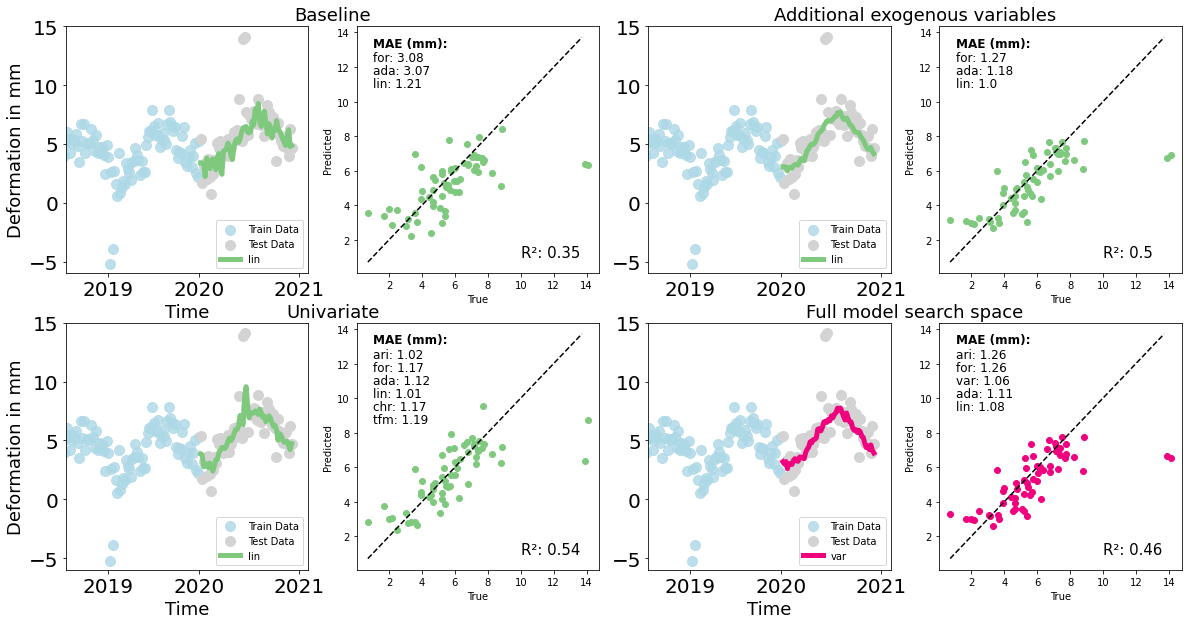

In [79]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))


for pack in [( axs[0, 0],axs[0, 1],"1"),( axs[0, 2],axs[0, 3],"2"),( axs[1, 0],axs[1, 1],"3"),( axs[1, 2],axs[1, 3],"0")]:
    display_predictions_2(
        fig,
        pack[0],
        d,
        fc[pack[2]],
        y_[ps_id],
        mae[pack[2]],
        colors=colors,
        fontsize=12,
        rs_fontsize=15,
        error_coords=[1, 7, 12],
        #error_coords=[10, -13.25, -2],
        rs_position=[10, 1],  #20,2
        add_stats_to_residual_plot=True,
        spacing=0.75, # 1.5
        provided_axes=pack[1],
        key=ps_id,
        shortening=False,
        ax2_inside=False,
        x_lim=[200, 360],
        y_lim=[-6,15], # []
        alphas=[0.0, 1.0],
        loc_2=[0.362, 0.78, 0.12, 0.18],
        marker="o",
    )

for c in [(1,0), (0,0)]:
    axs[c].set_ylabel("Deformation in mm", fontsize=18)

for c in [(0,0), (1,2), (1,0), (1,2)]:
    axs[c].set_xlabel("Time", fontsize=18)

naming = ["Baseline", "Additional exogenous variables", "Univariate", "Full model search space"]
for n,c in enumerate([(0,0), (0,2), (1,0), (1,2)]):
    axs[c].set_title(naming[n], fontsize=18, x=1.10)
    axs[c].legend(loc=4, fontsize=10)
plt.savefig("mdpi_3.pdf")